## Import Libraries

In [1]:
import os

from dotenv import load_dotenv
from huggingface_hub import login
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from stream_items import Item
from stream_llm import Stream_Item
from stream_data_tokennizer import Stream_Tokenizer

In [2]:
load_dotenv(override=True)

False

In [3]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

## HuggeingFace Login

In [4]:
hkf_token = os.getenv("HUGGING_KEY")
login(hkf_token)

## Load Dataset From HuggingFace

In [5]:
username = "KumudithaSilva"
dataset = f"{username}/items_llm_raw_lite"

train, val, test = Item.from_hub(dataset)

items = train + val + test

print(f"Loaded {len(items):,} items")

Loaded 22,000 items


## LLaMA SentencePiece Tokenizer

In [6]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

## Base Fine-tunning Prompt

In [7]:
def format_item(item):
    return f"""
Game: {item.name}
Peak CCU: {item.peakCCU}
Required Age: {item.required_age}
DLC Count: {item.dlcCount}
Supports Windows: {item.supportWindows}
Supports Mac: {item.supportMac}
Supports Linux: {item.supportLinux}
Positive Reviews: {item.positive}
Negative Reviews: {item.negative}
Achievements: {item.achievements}
Recommendations: {item.recommendations}
Release Date: {item.release_year}-{item.release_month}-{item.release_day}
Estimated Owners: {item.min_estimatedOwners} - {item.max_estimatedOwners}
Languages Supported: {item.supported_languages}
Developers: {item.num_developers}
Publishers: {item.num_publishers}
Categories: {item.num_categories}
Genres: {item.num_genres}
Description: {item.small_description}
"""

In [8]:
def format_stream_item(stream_item):
    return f"""
prompt: {stream_item.prompt},
completion: {stream_item.completion}
"""

In [9]:
tokenizer_obj = Stream_Tokenizer()

In [10]:
# token count in the dataset
token_counts = [tokenizer_obj.count_base_tokens(stream_item_data=format_item(item), tokenizer=tokenizer) for item in tqdm(items)]

  0%|          | 0/22000 [00:00<?, ?it/s]

## Token Distribution

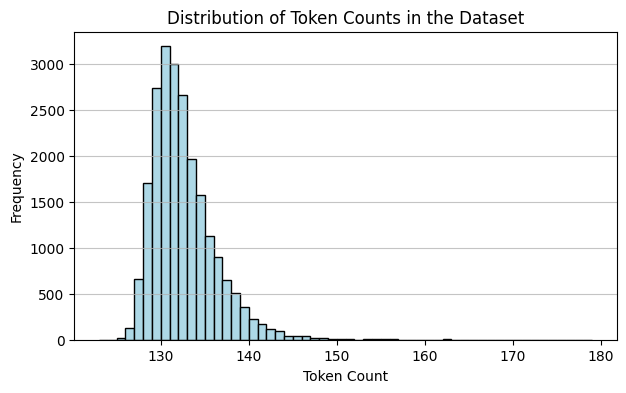

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(token_counts, bins=range(min(token_counts), max(token_counts) + 1), color='lightblue', edgecolor='black')
plt.title('Distribution of Token Counts in the Dataset')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Token Cutoff

In [12]:
CUT_OFF = 140

token_cut_off = [count for count in token_counts if count <= CUT_OFF]

print(f"Percentage of items with token count <= {CUT_OFF}: {len(token_cut_off) / len(items) * 100:.2f}%")

Percentage of items with token count <= 140: 97.35%


## Prompt Generation

In [13]:
stream_llm_train = []

for item in tqdm(train):
    out = tokenizer_obj.make_prompts(
        stream_item_data=format_item(item),
        tokenizer=tokenizer,
        max_tokens=140,
        do_round=True,
        do_truncate=True,
        price=item.price
    )

    stream_llm_train.append(Stream_Item(id=item.id, prompt=out["prompt"], completion=out["completion"]))

  0%|          | 0/17600 [00:00<?, ?it/s]

In [14]:
stream_llm_val = []

for item in tqdm(val):
    out = tokenizer_obj.make_prompts(
        stream_item_data=format_item(item),
        tokenizer=tokenizer,
        max_tokens=140,
        do_round=True,
        do_truncate=True,
        price=item.price
    )

    stream_llm_val.append(Stream_Item(id=item.id, prompt=out["prompt"], completion=out["completion"]))

  0%|          | 0/2200 [00:00<?, ?it/s]

In [15]:
stream_llm_test = []

for item in tqdm(test):
    out = tokenizer_obj.make_prompts(
        stream_item_data=format_item(item),
        tokenizer=tokenizer,
        max_tokens=140,
        do_round=False,
        do_truncate=True,
        price=item.price
    )

    stream_llm_test.append(Stream_Item(id=item.id, prompt=out["prompt"], completion=out["completion"]))

  0%|          | 0/2200 [00:00<?, ?it/s]

In [16]:
full_stream_llm = stream_llm_train + stream_llm_val + stream_llm_test

In [17]:
# token count in the dataset
token_counts_full = [tokenizer_obj.count_base_tokens(stream_item_data=format_stream_item(stream_item), tokenizer=tokenizer) for stream_item in tqdm(full_stream_llm)]

  0%|          | 0/22000 [00:00<?, ?it/s]

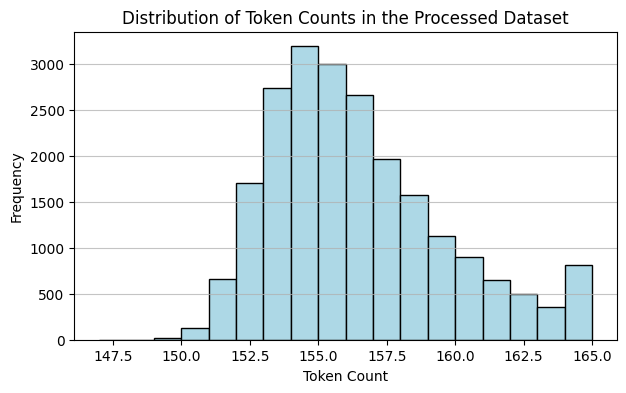

In [18]:
plt.figure(figsize=(7, 4))
plt.hist(token_counts_full, bins=range(min(token_counts_full), max(token_counts_full) + 1), color='lightblue', edgecolor='black')
plt.title('Distribution of Token Counts in the Processed Dataset')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Push to HuggingFace

In [19]:
username = "KumudithaSilva"
lite = f"{username}/stream_items_prompt_lite"

In [ ]:
train = stream_llm_train
val = stream_llm_val
test = stream_llm_test

Stream_Item.push_to_hub(lite, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/18 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            